# Import and cleaning function for Therion SQL import

SQL database exported with Therion can be loaded as networkx graph object (G) or karstnet object (Kg):

If the dataset require pre-processing before the statistical analysis, before intializing the Kg object, it is recommanded to first import the cave as a simple networkx object with the function:

`G = kn.io_func.networkx_from_therion_sql()`

1. Loads all the data from Therion sql 
2. Add flags on shots and stations
3. Regroupe nodes with same exact geographic coordinates
4. Rename nodes
5. Optionally remove flagged edges present in the SQL file ('dpl', and 'srf')
6. Returns a networkx graph

Once the graph (G is loaded), edges can be flagged and/or added, and nodes can be flagged. Flagging edges and nodes can be usefull for easily identifying edges that need to be removed before the analysis, or for isolating subsets of data (for example). 


The functions `add_edges`, `flag_nodes`, `flag_edges`, `remove_flagged_edges`:
1. enable to create edges and add manual flags on both edges and nodes
2. remove nodes with srf, dpl, rmv, art, or spl flags and add flagged add edges

Alternatively, the karstnet Kgraph object can be created directly with the kn `function kn.from_therion_sql()`


In [31]:
import karstnet as kn
import networkx as nx
import yaml

## 1 Import the Slovenian cave Migovec dataset as a graph object 
Survey data reference: ICCC, & JSDPT. (2024). Survey Data for the Tolminski Migovec Cave Exploration project (Version 2024.03.13) [Dataset]. Zenodo. https://doi.org/DOI: 10.5281/ZENODO.108130

In [32]:
#load graph graph data

metadata = {}
metadata['cavename'] = 'Migovec'
# metadata['crs'] = 'epsg:3912' 
# metadata['rights'] = 'CC-BY-NC-SA 4.0'
# metadata['citation'] = 'ICCC, & JSDPT. (2024). Survey Data for the Tolminski Migovec Cave Exploration project (Version 2024.03.13) [Dataset]. Zenodo. https://doi.org/DOI: 10.5281/ZENODO.108130'

#default options are: loading without removing flagged edges
G = kn.io_func.networkx_from_therion_sql('../data/Migovec.sql') # adapt the path if needed
G.graph = metadata


Therion Import -- Importing all links (including splays) -- 0.10099124908447266s
Therion Import -- Importing all nodes data (including splays) -- 0.10750126838684082s
Therion Import -- Create initial graph with all the data points (including splays) -- 0.13254833221435547s
Therion Import -- Combine Stations with identical x,y,z -- 0.16560125350952148s
0/7294 unique positions
1000/7294 unique positions
2000/7294 unique positions
3000/7294 unique positions
4000/7294 unique positions
5000/7294 unique positions
6000/7294 unique positions
7000/7294 unique positions
Therion Import -- Rename nodes -- 4.5221107006073s
0/7294 nodes to rename
1000/7294 nodes to rename
2000/7294 nodes to rename
3000/7294 nodes to rename
4000/7294 nodes to rename
5000/7294 nodes to rename
6000/7294 nodes to rename
7000/7294 nodes to rename
Therion Import -- concatenate old ic in a dictionnary -- 4.559152603149414s
Therion Import -- Relabel nodes -- 4.560086250305176s
Therion Import -- remove self links -- 4.569916

In [33]:
# # Remark : a Kgraph object can be loaded directly from a .sql file
# Kg = kn.from_therion_sql('../data/Migovec.sql')
# G = Kg.graph # extract the main graph from the Kgraph object


## 2 Clean graph

### 2.1 Remove duplicates and surface shots flagged in the Therion sql file.

In [34]:
# create a copy if you want to compare before and after cleaning
H = G.copy()
# clean flagged edges
kn.clean.remove_flagged_edges(H) # in this case, removing the flagged duplicate and surface points disconnected parts from each other
print(f'Initial Graph size: {len(G)}, Graph size after removing flagged edges: {len(H)}')

# # alternatively, the graph can be loaded directly without the duplicate or surface points:
# H = kn.io_func.networkx_from_therion_sql('../data/Migovec.sql', remove_flagged_edges=True)


Initial Graph size: 7294, Graph size after removing flagged edges: 6977


### 2.2 Flag/clean edges

It is possible to create and flag edges.

- To create one or multiple edges, write a dictionnary with the flag as key, and a list of list of node id as values.
    - To create edges that should stay on the graph, use the flag 'add', or any other flags of your choice.
    - by default the flags 'srf', 'dpl', 'rmv', 'art', 'spl' will be removed if remove_flagged_edges is set to True.
- If the edge already exist, then a flag will be added edge or node

the node id are the full address, which is the full path describing the station in the sql file. This full address can be found in the  ```fulladdress``` dictionnary attached to the graph

#### Edge flags

Therion edge (shot) flags:
- ```dpl``` = duplicate
- ```srf``` = surface shots 

Other edge flags ideas:
- ```add``` = add
- ```rmv``` = remove
- ```art``` = artificial (ex. tunnel)
- ```spl``` = splay (for example star shape shots in large rooms)

note: if the edges flagged does not exist yet, the function creates the edge

#### fulladdress

For stability purposes, it is recommanded to store the edges to add with unique and unchanging node ids. For example the "fulladdress", which is a Therion and Survex concept, which allows you to identify the node in the arborescence of survey. 

For example, the Migovec survey is organized in multiple suvey, sub-survey, sub-sub-survey, ... . In the fulladdress "system_migovec.vrtnarija_vilinska.vrtnarija.xanadont.2" the node id is named "2" in the original therion dataset, and is part of the survey "xanadont", which is part of "fvrtnarija", which is part of "vrtnarija_vilinska", which exists in the main survey "system_migovec".

In the case of cave organized in one single survey. The path will be Cavename.StationID




In [35]:

#create a dictionnary of flag keys, containing the list of of edges to flag. 
#----------------------------------------------------------------
# a good way to store dictionnaries are yaml files
with open('../data/corrections.yaml') as f:
            correction = yaml.safe_load(f)
flagged_edges = correction[G.graph['cavename']]['edge_flags']

# #alternatively, a dictionnary can be created like this
# flagged_edges = {'add': [['system_migovec.vrtnarija_vilinska.vrtnarija.xanadont.2','system_migovec.vrtnarija_vilinska.vrtnarija.cuckoos_nest.35'],
#                         ['system_migovec.vrtnarija_vilinska.vrtnarija.highway32.12','system_migovec.vrtnarija_vilinska.vrtnarija.gravity.2']],
#                   'dpl': [['system_migovec.vrtnarija_vilinska.vrtnarija.xanadont.2','system_migovec.vrtnarija_vilinska.vrtnarija.xanadont.1'],
#                         ['system_migovec.primadona_ubend_mona_tip.mona_tip.mona_tip2.35','system_migovec.primadona_ubend_mona_tip.mona_tip.cloacamaxima.45'],
#                         ['system_migovec.primadona_ubend_mona_tip.mona_tip.cloacamaxima.45','system_migovec.primadona_ubend_mona_tip.mona_tip.cloacamaxima.46'],
#                         ['system_migovec.primadona_ubend_mona_tip.mona_tip.cloacamaxima.46','system_migovec.primadona_ubend_mona_tip.mona_tip.cloacamaxima.47']]}



# this function add flags on edges. if the edge does not exist, it creates it
# however, if the node does not exist, it creates an error
I = H.copy()
kn.clean.flag_edges(I, flagged_edges, dict_address = nx.get_node_attributes(I,'fulladdress'))
kn.clean.remove_flagged_edges(I)



print(f'Initial Graph size: nodes={len(G)}, edges={G.size()}')
print(f'Graph size after removing already flagged edges: nodes={len(H)}, edges={H.size()}') 
print(f'Graph size after flagging/adding and removing additional edges: nodes={len(I)}, edges={I.size()}')


flag_edges - adding manual edges flags: dict_keys(['add', 'rmv'])
add
rmv
Initial Graph size: nodes=7294, edges=7353
Graph size after removing already flagged edges: nodes=6977, edges=6992
Graph size after flagging/adding and removing additional edges: nodes=6973, edges=7014


## 3 Flag nodes - example with a smaller cave
To add a node flag, create a dictionnary with the flag as key, and a list of node id to flag.

#### Therion node (station) flags: 

- ```ent``` = entrance
- ```con``` = continuation
- ```fix``` = fixed 
- ```spr``` = spring
- ```sin``` = sink
- ```dol``` = doline
- ```dig``` = dig 
- ```air``` = air-draught
- ```ove``` = overhang
- ```arc``` = arch attributes  

Any other flag can be added for individual cleaning/selection purposes


Therion Import -- Importing all links (including splays) -- 0.006188631057739258s
Therion Import -- Importing all nodes data (including splays) -- 0.006769895553588867s
Therion Import -- Create initial graph with all the data points (including splays) -- 0.008032798767089844s
Therion Import -- Combine Stations with identical x,y,z -- 0.1134648323059082s
0/78 unique positions
Therion Import -- Rename nodes -- 0.11406540870666504s
0/78 nodes to rename
Therion Import -- concatenate old ic in a dictionnary -- 0.11409235000610352s
Therion Import -- Relabel nodes -- 0.1141047477722168s
Therion Import -- remove self links -- 0.1142582893371582s
Therion Import --add dictionnaries to graph -- 0.11427044868469238s
Therion Import -- add splays -- 0.11427521705627441s
Therion Import -- add fulladdress -- 0.11551928520202637s
Therion Import -- add flags
Therion Import -- add sql ids -- 0.11578583717346191s
Therion Import -- remove isolated nodes -- 0.11580944061279297s
Networkx graph successfully c

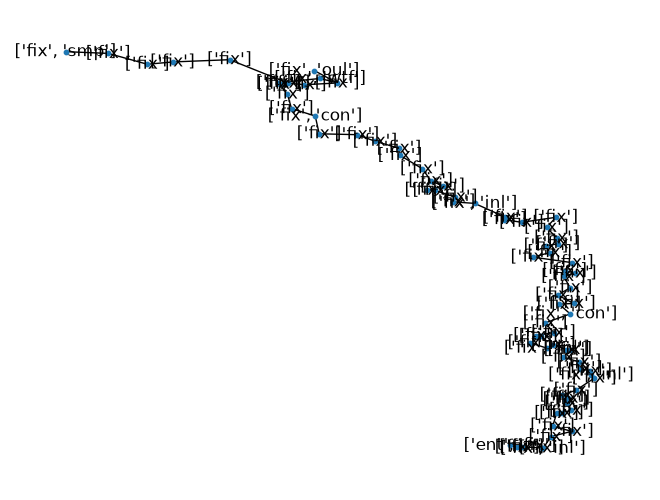

In [36]:
metadata = {}
metadata['cavename'] = 'ReveEveille'
metadata['crs'] = 'local'
metadata['rights'] = 'CC-BY-NC-SA 4.0'
metadata['citation'] = 'Centre Terre. (2024). Survey Data for the Ultima Patagonia Cave Exploration project [Dataset]. https://github.com/tr1813/ultima-patag'

G = kn.io_func.networkx_from_therion_sql('../data/ReveEveille.sql')
#this is optional, but can help later
G.graph = metadata

flagged_nodes = {  'con': ['ReveEveille.cpff.23', 'ReveEveille.Suite.9'],
                    'inl': ['ReveEveille.CPF.4', 'ReveEveille.cpff.4', 'ReveEveille.cpff.38', 'ReveEveille.cpff.30'],
                    'oul': ['ReveEveille.Suite.16'],
                    'smp': ['ReveEveille.Suite.24'],
                    'wtf': ['ReveEveille.Suite.14']}


kn.clean.flag_nodes(G, flagged_nodes, dict_address = nx.get_node_attributes(G,'fulladdress'))

labels = nx.get_node_attributes(G, 'flags') 
nx.draw(G,
        pos = kn.utils.get_pos2d(G),
        labels = labels,
        node_size = 10)



## 4 Create Kgraph object

In [37]:
Kg = kn.from_networkx(G, pos_attr='pos', verbose=True)


This network contains 1 connected components
Karstnet graph successfully created from networkx graph !



## Visualization
See notebook `B-Visualize-karsnet-graphs.ipynb`.